In [7]:
!python test_hgpg2.py --gpu 1  --img-path "/home/share/clr/share/data/Coronary_nc_Dengzhenrong/images/test/IM000190_21.png"

Using GPU 1: NVIDIA A10

Frangi Filter Test
Device: cuda:1
Image: Real image
Sigmas: (1, 2, 4)
Beta: 0.5, C: 15
Normalization: percentile (threshold_percentile=75)
Image loaded: (512, 512)

Processing...
Output range: [0.000000e+00, 9.988870e-01]
Output mean:  1.055119e-03
Output std:   5.539543e-03
Non-zero pixels: 65536 (25.00%)
Figure(2000x2000)

✓ Done!


In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
import math
import pdb

import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
import argparse
from PIL import Image

# This is a PyTorch data augmentation library, that takes PyTorch Tensor as input
# Functions can be applied in the __getitem__ function to do augmentation on the fly during training.
# These functions can be easily parallelized by setting 'num_workers' in pytorch dataloader.

# tensor_img: 1, C, (D), H, W

def gaussian_noise(tensor_img, std, mean=0):
    
    return tensor_img + torch.randn(tensor_img.shape).to(tensor_img.device) * std + mean

def generate_2d_gaussian_kernel(kernel_size, sigma):
    # Generate a meshgrid for the kernel
    x = torch.arange(-kernel_size // 2 + 1, kernel_size // 2 + 1, dtype=torch.float32)
    y = torch.arange(-kernel_size // 2 + 1, kernel_size // 2 + 1, dtype=torch.float32)
    x, y = torch.meshgrid(x, y)

    # Calculate the 2D Gaussian kernel
    kernel = torch.exp(-(x ** 2 + y ** 2) / (2 * sigma ** 2))
    kernel = kernel / (2 * math.pi * sigma ** 2)
    kernel = kernel / kernel.sum()

    return kernel.unsqueeze(0).unsqueeze(0)

def generate_3d_gaussian_kernel(kernel_size, sigma):
    # Generate a meshgrid for the kernel
    x = torch.arange(-kernel_size // 2 + 1, kernel_size // 2 + 1, dtype=torch.float32)
    y = torch.arange(-kernel_size // 2 + 1, kernel_size // 2 + 1, dtype=torch.float32)
    z = torch.arange(-kernel_size // 2 + 1, kernel_size // 2 + 1, dtype=torch.float32)
    x, y, z = torch.meshgrid(x, y, z)

    # Calculate the 3D Gaussian kernel
    kernel = torch.exp(-(x ** 2 + y ** 2 + z ** 2) / (2 * sigma ** 2))
    kernel = kernel / (2 * math.pi * sigma ** 2) ** 1.5
    kernel = kernel / kernel.sum()

    return kernel.unsqueeze(0).unsqueeze(0)

def gaussian_blur(tensor_img, sigma_range=[0.5, 1.0]):

    sigma = torch.rand(1) * (sigma_range[1] - sigma_range[0]) + sigma_range[0]
    kernel_size = 2 * math.ceil(3 * sigma) + 1
    
    if len(tensor_img.shape) == 5:
        dim = '3d'
        kernel = generate_3d_gaussian_kernel(kernel_size, sigma).to(tensor_img.device)
        padding = [kernel_size // 2 for i in range(3)]

        return F.conv3d(tensor_img, kernel, padding=padding)
    elif len(tensor_img.shape) == 4:
        dim = '2d'
        kernel = generate_2d_gaussian_kernel(kernel_size, sigma).to(tensor_img.device)
        padding = [kernel_size // 2 for i in range(2)]

        return F.conv2d(tensor_img, kernel, padding=padding)
    else:
        raise ValueError('Invalid input tensor dimension, should be 5d for volume image or 4d for 2d image')


def brightness_additive(tensor_img, std, mean=0, per_channel=False):
    
    if per_channel:
        C = tensor_img.shape[1]
    else:
        C = 1

    if len(tensor_img.shape) == 5:
        rand_brightness = torch.normal(mean, std, size=(1, C, 1, 1, 1)).to(tensor_img.device)
    elif len(tensor_img.shape) == 4:
        rand_brightness = torch.normal(mean, std, size=(1, C, 1, 1)).to(tensor_img.device)
    else:
        raise ValueError('Invalid input tensor dimension, should be 5d for volume image or 4d for 2d image')

    return tensor_img + rand_brightness


def brightness_multiply(tensor_img, multiply_range=[0.7, 1.3], per_channel=False):

    if per_channel:
        C = tensor_img.shape[1]
    else:
        C = 1

    assert multiply_range[1] > multiply_range[0], 'Invalid range'

    span = multiply_range[1] - multiply_range[0]
    if len(tensor_img.shape) == 5:
        rand_brightness = torch.rand(size=(1, C, 1, 1, 1)).to(tensor_img.device) * span + multiply_range[0]
    elif len(tensor_img.shape) == 4:
        rand_brightness = torch.rand(size=(1, C, 1, 1)).to(tensor_img.device) * span + multiply_range[0]
    else:
        raise ValueError('Invalid input tensor dimension, should be 5d for volume image or 4d for 2d image')

    return tensor_img * rand_brightness


def gamma(tensor_img, gamma_range=(0.5, 2), per_channel=False, retain_stats=True):
    
    if len(tensor_img.shape) == 5:
        dim = '3d'
        _, C, D, H, W = tensor_img.shape
    elif len(tensor_img.shape) == 4:
        dim = '2d'
        _, C, H, W = tensor_img.shape
    else:
        raise ValueError('Invalid input tensor dimension, should be 5d for volume image or 4d for 2d image')
    
    tmp_C = C if per_channel else 1
    tensor_img = tensor_img.view(tmp_C, -1)
    minm, _ = tensor_img.min(dim=1)
    maxm, _ = tensor_img.max(dim=1)
    minm, maxm = minm.unsqueeze(1), maxm.unsqueeze(1) # unsqueeze for broadcast machanism

    rng = maxm - minm

    mean = tensor_img.mean(dim=1).unsqueeze(1)
    std = tensor_img.std(dim=1).unsqueeze(1)
    gamma = torch.rand(C, 1).to(tensor_img.device) * (gamma_range[1] - gamma_range[0]) + gamma_range[0]

    tensor_img = torch.pow((tensor_img - minm) / rng, gamma) * rng + minm

    if retain_stats:
        tensor_img -= tensor_img.mean(dim=1).unsqueeze(1)
        tensor_img = tensor_img / tensor_img.std(dim=1).unsqueeze(1) * std + mean

    if dim == '3d':
        return tensor_img.view(1, C, D, H, W)
    else:
        return tensor_img.view(1, C, H, W)
        
def contrast(tensor_img, contrast_range=(0.65, 1.5), per_channel=False, preserve_range=True):

    if len(tensor_img.shape) == 5:
        dim = '3d'
        _, C, D, H, W = tensor_img.shape
    elif len(tensor_img.shape) == 4:
        dim = '2d'
        _, C, H, W = tensor_img.shape
    else:
        raise ValueError('Invalid input tensor dimension, should be 5d for volume image or 4d for 2d image')

    tmp_C = C if per_channel else 1
    tensor_img = tensor_img.view(tmp_C, -1)
    minm, _ = tensor_img.min(dim=1)
    maxm, _ = tensor_img.max(dim=1)
    minm, maxm = minm.unsqueeze(1), maxm.unsqueeze(1) # unsqueeze for broadcast machanism


    mean = tensor_img.mean(dim=1).unsqueeze(1)
    factor = torch.rand(C, 1).to(tensor_img.device) * (contrast_range[1] - contrast_range[0]) + contrast_range[0]

    tensor_img = (tensor_img - mean) * factor + mean

    if preserve_range:
        tensor_img = torch.clamp(tensor_img, min=minm, max=maxm)

    if dim == '3d':
        return tensor_img.view(1, C, D, H, W)
    else:
        return tensor_img.view(1, C, H, W)

def mirror(tensor_img, axis=0):

    '''
    Args:
        tensor_img: an image with format of pytorch tensor
        axis: the axis for mirroring. 0 for the first image axis, 1 for the second, 2 for the third (if volume image)
    '''


    if len(tensor_img.shape) == 5:
        dim = '3d'
        assert axis in [0, 1, 2], "axis should be either 0, 1 or 2 for volume images"

    elif len(tensor_img.shape) == 4:
        dim = '2d'
        assert axis in [0, 1], "axis should be either 0 or 1 for 2D images"
    else:
        raise ValueError('Invalid input tensor dimension, should be 5d for volume image or 4d for 2d image')


    return torch.flip(tensor_img, dims=[2+axis])


def random_scale_rotate_translate_2d(tensor_img, tensor_lab, scale, rotate, translate):

    # implemented with affine transformation

    if isinstance(scale, float) or isinstance(scale, int):
        scale = [scale] * 2
    if isinstance(translate, float) or isinstance(translate, int):
        translate = [translate] * 2
    

    scale_x = 1 - scale[0] + np.random.random() * 2*scale[0]
    scale_y = 1 - scale[1] + np.random.random() * 2*scale[1]
    shear_x = np.random.random() * 2*scale[0] - scale[0] 
    shear_y = np.random.random() * 2*scale[1] - scale[1]
    translate_x = np.random.random() * 2*translate[0] - translate[0]
    translate_y = np.random.random() * 2*translate[1] - translate[1]

    theta_scale = torch.tensor([[scale_x, shear_x, translate_x], 
                                [shear_y, scale_y, translate_y],
                                [0, 0, 1]]).float()
    angle = (float(np.random.randint(-rotate, max(rotate, 1))) / 180.) * math.pi

    theta_rotate = torch.tensor([[math.cos(angle), -math.sin(angle), 0],
                                [math.sin(angle), math.cos(angle), 0],
                                [0, 0, 1]]).float()
    
    theta = torch.mm(theta_scale, theta_rotate)[0:2, :]
    grid = F.affine_grid(theta.unsqueeze(0), tensor_img.size(), align_corners=True).to(tensor_img.device)

    tensor_img = F.grid_sample(tensor_img, grid, mode='bilinear', padding_mode='zeros', align_corners=True)
    tensor_lab = F.grid_sample(tensor_lab.float(), grid, mode='nearest', padding_mode='zeros', align_corners=True).long()

    return tensor_img, tensor_lab

def random_scale_rotate_translate_3d(tensor_img, tensor_lab, scale=0.3, rotate=45, translate=0.1, shear=0.05):
    '''
    The axis order of SimpleITK is x,y,z
    The axis order of numpy/tensor is z,y,x
    The arguments of all transformation should use the numpy/tensor order: [z,y,x]

    '''
    
    if isinstance(scale, float) or isinstance(scale, int):
        scale = [scale] * 3
    if isinstance(translate, float) or isinstance(translate, int):
        translate = [translate] * 3
    if isinstance(rotate, float) or isinstance(rotate, int):
        rotate = [rotate] * 3
    if isinstance(shear, float) or isinstance(shear, int):
        shear = [shear] * 3

    scale_x = np.random.uniform(low=1-scale[0], high=1/(1-scale[0]))
    scale_y = np.random.uniform(low=1-scale[1], high=1/(1-scale[1]))
    scale_z = np.random.uniform(low=1-scale[2], high=1/(1-scale[2]))

    shear_xy = np.random.uniform(-shear[0], shear[0]) # contribution of y index to x axis
    shear_xz = np.random.uniform(-shear[0], shear[0]) # contribution of z index to x axis
    shear_yx = np.random.uniform(-shear[1], shear[1]) # contribution of x index to y axis
    shear_yz = np.random.uniform(-shear[1], shear[1]) # contribution of z index to y axis
    shear_zx = np.random.uniform(-shear[2], shear[2]) # contribution of x index to z axis
    shear_zy = np.random.uniform(-shear[2], shear[2]) # contribution of y index to z axis

    translate_x = np.random.uniform(-translate[0], translate[0])
    translate_y = np.random.uniform(-translate[1], translate[1])
    translate_z = np.random.uniform(-translate[2], translate[2])


    theta_scale = torch.tensor([[scale_x, shear_xy, shear_xz, translate_x],
                                [shear_yx, scale_y, shear_yz, translate_y],
                                [shear_zx, shear_zy, scale_z, translate_z], 
                                [0, 0, 0, 1]]).float()
    angle_x = (float(np.random.randint(-rotate[0], max(rotate[0], 1))) / 180.) * math.pi 
    # rotate along x axis (x index fix, rotae in yz plane)
    angle_y = (float(np.random.randint(-rotate[1], max(rotate[1], 1))) / 180.) * math.pi
    # rotate along y axis (y index fix, rotate in xz plane)
    angle_z = (float(np.random.randint(-rotate[2], max(rotate[2], 1))) / 180.) * math.pi
    # rotate along z axis (z index fix, rotate in xy plane)
    
    theta_rotate_x = torch.tensor([[1, 0, 0, 0],
                                    [0, math.cos(angle_x), -math.sin(angle_x), 0],
                                    [0, math.sin(angle_x), math.cos(angle_x), 0],
                                    [0, 0, 0, 1]]).float()
    theta_rotate_y = torch.tensor([[math.cos(angle_y), 0, -math.sin(angle_y), 0],
                                    [0, 1, 0, 0],
                                    [math.sin(angle_y), 0, math.cos(angle_y), 0],
                                    [0, 0, 0, 1]]).float()
    theta_rotate_z = torch.tensor([[math.cos(angle_z), -math.sin(angle_z), 0, 0],
                                    [math.sin(angle_z), math.cos(angle_z), 0, 0],
                                    [0, 0, 1, 0],
                                    [0, 0, 0, 1]]).float()

    theta = torch.mm(theta_rotate_x, theta_rotate_y)
    theta = torch.mm(theta, theta_rotate_z)
    
    theta = torch.mm(theta, theta_scale)[0:3, :].unsqueeze(0)
    grid = F.affine_grid(theta, tensor_img.size(), align_corners=True).to(tensor_img.device)
    tensor_img = F.grid_sample(tensor_img, grid, mode='bilinear', padding_mode='zeros', align_corners=True)
    tensor_lab = F.grid_sample(tensor_lab.float(), grid, mode='nearest', padding_mode='zeros', align_corners=True).long()

    return tensor_img, tensor_lab
    


  

def crop_2d(tensor_img, tensor_lab, crop_size, mode):
    assert mode in ['random', 'center'], "Invalid Mode, should be \'random\' or \'center\'"
    if isinstance(crop_size, int):
        crop_size = [crop_size] * 2

    _, _, H, W = tensor_img.shape

    diff_H = H - crop_size[0]
    diff_W = W - crop_size[1]
    
    if mode == 'random':
        rand_x = np.random.randint(0, max(diff_H, 1))
        rand_y = np.random.randint(0, max(diff_W, 1))
    else:
        rand_x = diff_H // 2
        rand_y = diff_W // 2

    cropped_img = tensor_img[:, :, rand_x:rand_x+crop_size[0], rand_y:rand_y+crop_size[1]]
    cropped_lab = tensor_lab[:, :, rand_x:rand_x+crop_size[0], rand_y:rand_y+crop_size[1]]

    return cropped_img.contiguous(), cropped_lab.contiguous()


def crop_3d(tensor_img, tensor_lab, crop_size, mode):
    assert mode in ['random', 'center'], "Invalid Mode, should be \'random\' or \'center\'"
    if isinstance(crop_size, int):
        crop_size = [crop_size] * 3

    _, _, D, H, W = tensor_img.shape

    diff_D = D - crop_size[0]
    diff_H = H - crop_size[1]
    diff_W = W - crop_size[2]
    
    if mode == 'random':
        rand_z = np.random.randint(0, max(diff_D, 1))
        rand_y = np.random.randint(0, max(diff_H, 1))
        rand_x = np.random.randint(0, max(diff_W, 1))
    else:
        rand_z = diff_D // 2
        rand_y = diff_H // 2
        rand_x = diff_W // 2

    cropped_img = tensor_img[:, :, rand_z:rand_z+crop_size[0], rand_y:rand_y+crop_size[1], rand_x:rand_x+crop_size[2]]
    cropped_lab = tensor_lab[:, :, rand_z:rand_z+crop_size[0], rand_y:rand_y+crop_size[1], rand_x:rand_x+crop_size[2]]

    return cropped_img.contiguous(), cropped_lab.contiguous()


def crop_around_coordinate_3d(tensor_img, tensor_lab, crop_size, coordinate, mode):
    assert mode in ['random', 'center'], "Invalid Mode, should be \'random\' or \'center\'"
    if isinstance(crop_size, int):
        crop_size = [crop_size] * 3

    z, y, x = coordinate

    _, _, D, H, W = tensor_img.shape

    diff_D = D - crop_size[0]
    diff_H = H - crop_size[1]
    diff_W = W - crop_size[2]
    
    
    if mode == 'random':
        min_z = max(0, z-crop_size[0])
        max_z = min(diff_D, z+crop_size[0])
        min_y = max(0, y-crop_size[1])
        max_y = min(diff_H, y+crop_size[1])
        min_x = max(0, x-crop_size[2])
        max_x = min(diff_W, x+crop_size[2])
        
        rand_z = np.random.randint(min_z, max_z)
        rand_y = np.random.randint(min_y, max_y)
        rand_x = np.random.randint(min_x, max_x)
    else:
        min_z = max(0, z - math.ceil(crop_size[0] / 2))
        rand_z = min(min_z, D - crop_size[0])
        min_y = max(0, y - math.ceil(crop_size[1] / 2))
        rand_y = min(min_y, H - crop_size[1])
        min_x = max(0, x - math.ceil(crop_size[2] / 2))
        rand_x = min(min_x, W - crop_size[2])

    cropped_img = tensor_img[:, :, rand_z:rand_z+crop_size[0], rand_y:rand_y+crop_size[1], rand_x:rand_x+crop_size[2]]
    cropped_lab = tensor_lab[:, :, rand_z:rand_z+crop_size[0], rand_y:rand_y+crop_size[1], rand_x:rand_x+crop_size[2]]

    return cropped_img.contiguous(), cropped_lab.contiguous()



In [23]:
def create_layer(Sigma, device):
    S_round = torch.round(3*Sigma)
    grid_range = torch.arange(-S_round, S_round+1, 1)
    [X,Y] = torch.meshgrid(grid_range,grid_range)

    DGaussxx = 1/(2*math.pi*pow(Sigma,4)) * (X**2/pow(Sigma,2) - 1) * torch.exp(-(X**2 + Y**2)/(2*pow(Sigma,2)))
    DGaussxy = 1/(2*math.pi*pow(Sigma,6)) * (X*Y) * torch.exp(-(X**2 + Y**2)/(2*pow(Sigma,2)))   
    DGaussyy = 1/(2*math.pi*pow(Sigma,4)) * (Y**2/pow(Sigma,2) - 1) * torch.exp(-(X**2 + Y**2)/(2*pow(Sigma,2)))
    Dlayer = torch.nn.Conv2d(1, 3, grid_range.shape[0], padding='same', bias = False, device = device)
    Dlayer.weight.data[0,0,:,:] = DGaussxx
    Dlayer.weight.data[1,0,:,:] = DGaussxy
    Dlayer.weight.data[2,0,:,:] = DGaussyy

    return Dlayer

def Hessian2D(Dlayer, frames, device):
    # Input : frames [B,1,H,W] grey scale image, dlayer conv layers built with sigma
    # Output: The 2d Hessian of the image
    with torch.no_grad():
        frames = frames.to(device)
        out = Dlayer(frames)

    return out[:,None,0,:,:], out[:,None,1,:,:], out[:,None,2,:,:]


def eig2image(Dxx,Dxy,Dyy):
    # This function eig2image calculates the eigen values from the
    # hessian matrix, sorted by abs value. And gives the direction
    # of the ridge (eigenvector smallest eigenvalue) .
    # input:Dxx,Dxy,Dyy图像的二阶导数
    # output:Lambda1,Lambda2,Ix,Iy
    #Compute the eigenvectors of J, v1 and v2


    tmp = torch.sqrt( (Dxx - Dyy)**2 + 4*Dxy**2)

    v2x = 2*Dxy
    v2y = Dyy - Dxx + tmp

    mag = torch.sqrt(v2x**2 + v2y**2)
    i = torch.Tensor(mag!=0)

    v2x[i==True] = v2x[i==True]/mag[i==True]
    v2y[i==True] = v2y[i==True]/mag[i==True]

    v1x = -v2y 
    v1y = v2x

    mu1 = 0.5*(Dxx + Dyy + tmp)
    mu2 = 0.5*(Dxx + Dyy - tmp)

    check=abs(mu1)>abs(mu2)
            
    Lambda1=mu1.clone().detach()
    Lambda1[check==True] = mu2[check==True]
    Lambda2=mu2.clone().detach()
    Lambda2[check==True] = mu1[check==True]
    
    Ix=v1x
    Ix[check==True] = v2x[check==True]
    Iy=v1y
    Iy[check==True] = v2y[check==True]
    
    return Lambda1,Lambda2,Ix,Iy

def FrangiFilter2D(I, device, ext_option=None):
    # device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    I = I.type(torch.float32)

    defaultoptions = {'FrangiScaleRange':(1,15), 'FrangiScaleRatio':2, 'FrangiBetaOne':0.5, 'FrangiBetaTwo':15,'BlackWhite':True};  
    options = ext_option if ext_option else defaultoptions 

    sigmas=torch.arange(options['FrangiScaleRange'][0],options['FrangiScaleRange'][1],options['FrangiScaleRatio'])
    sigmas.sort()#升序
    print(sigmas)

    beta  = torch.tensor(2*pow(options['FrangiBetaOne'],2),device=device)
    c     = torch.tensor(2*pow(options['FrangiBetaTwo'],2),device=device)

    #存储滤波后的图像
    shape=(I.shape[0],len(sigmas),I.shape[2],I.shape[3])
    ALLfiltered=torch.zeros(shape, device=device) 

    #Frangi filter for all sigmas 
    Rb=0
    S2=0

    
    Dlayers = [create_layer(sigma, device) for sigma in sigmas]

    for i in range(len(sigmas)):

        #Make 2D hessian
        [Dxx,Dxy,Dyy] = Hessian2D(Dlayers[i],I,device)

        #Correct for scale 
        Dxx = pow(sigmas[i],2)*Dxx  
        Dxy = pow(sigmas[i],2)*Dxy  
        Dyy = pow(sigmas[i],2)*Dyy
         
        #Calculate (abs sorted) eigenvalues and vectors  
        [Lambda2,Lambda1,Ix,Iy]=eig2image(Dxx,Dxy,Dyy)  


        #Compute some similarity measures  
        Lambda1[Lambda1==0] = torch.finfo(torch.float64).eps

        Rb = (Lambda2/Lambda1)**2  
        S2 = Lambda1**2 + Lambda2**2
        
        #Compute the output image
        Ifiltered = torch.exp(-Rb/ beta) * (torch.ones(I.shape, device=device)-torch.exp(-S2/c))

        #see pp. 45  
        if(options['BlackWhite']): 
            Ifiltered[Lambda1<0]=0
        else:
            Ifiltered[Lambda1>0]=0
        
        #store the results in 3D matrices  
        ALLfiltered[:,i,:,:] = Ifiltered[:,0,:,:]
        #ALLangles[:,:,i] = angles

        # Return for every pixel the value of the scale(sigma) with the maximum   
        # output pixel value  
    if len(sigmas) > 1:
        maxout , _ = torch.max(ALLfiltered, dim = 1)
    maxout = maxout[:,None,:,:]
    return maxout


class FIConv2d(nn.Module):
    def __init__(self, opt):
        super(FIConv2d, self).__init__()
        self.defaultoptions = opt
        self.frangi_filter = FrangiFilter2D
        # self.base_conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding='same')

    def forward(self, x):
        # (B, 1, H, W)
        x = self.frangi_filter(x, x.device, self.defaultoptions)
        # x = self.base_conv(x)
        return x

Using GPU 1: NVIDIA A10

Frangi Filter Test
Device: cuda:1
Image: Real image
Sigmas: (1, 3, 5, 7, 9)
Beta: 0.5, C: 15
Normalization: percentile (threshold_percentile=75)
Image loaded: (512, 512)

Processing...
tensor([1, 3, 5, 7, 9])
tensor([1, 3, 5, 7, 9])
Output range: [0.000000e+00, 8.681934e-01]
Output mean:  1.053786e-02
Output std:   4.683765e-02
Non-zero pixels: 91092 (34.75%)


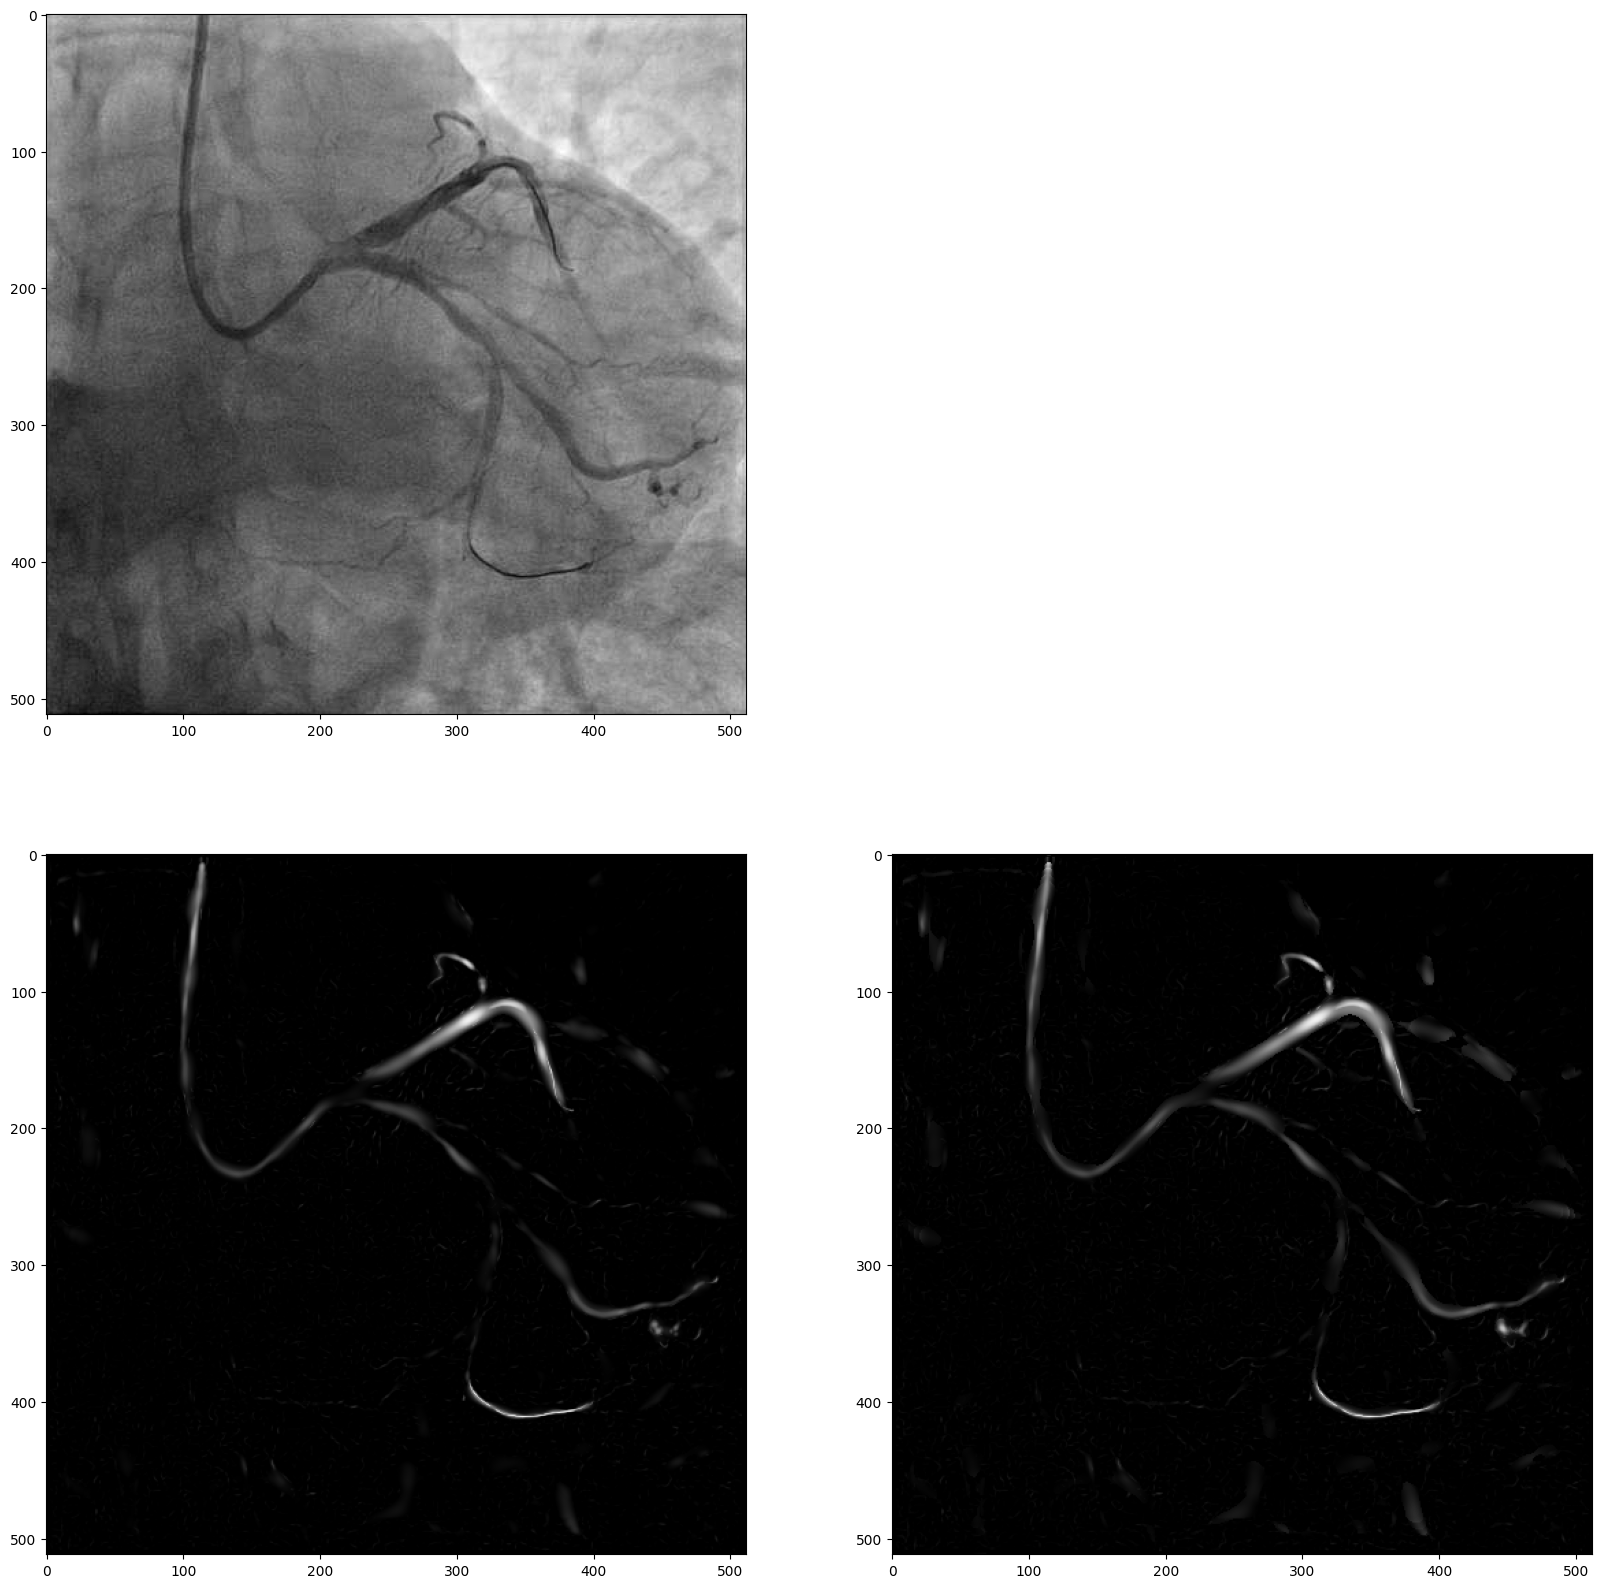


✓ Done!


In [44]:
# import torch


def visualize_simple(input_img, output, output2, method_name='', filename='frangi_output.png'):
    """简化的可视化：只显示原始图和响应输出"""
    input_np = input_img[0, 0].numpy()
    output_np = output[0, 0].numpy()
    output_np2 = output2[0, 0].numpy()
    plt.figure(figsize=(20, 20))
    plt.subplot(2, 2, 1)
    plt.imshow(input_np, cmap='gray')
    plt.subplot(2, 2, 3)
    plt.imshow(output_np, cmap='gray')
    plt.subplot(2, 2, 4)
    plt.imshow(output_np2, cmap='gray')
    plt.show()

def load_real_image(img_path):
    """加载真实医学图像"""
    img = Image.open(img_path).convert('L')
    img = np.array(img, dtype=np.float32)
    # img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    
    print(f"Image loaded: {img.shape}")
    return torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)


def get_device(gpu_id=None):
    """获取设备"""
    if gpu_id is not None:
        if not torch.cuda.is_available():
            print(f"Warning: CUDA not available, using CPU")
            return torch.device('cpu')
        if gpu_id >= torch.cuda.device_count():
            print(f"Warning: GPU {gpu_id} not available, using GPU 0")
            gpu_id = 0
        device = torch.device(f'cuda:{gpu_id}')
        print(f"Using GPU {gpu_id}: {torch.cuda.get_device_name(gpu_id)}")
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        if device.type == 'cuda':
            print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        else:
            print("Using CPU")
    return device


# =========================================================================
# FrangiSpectralFilter with Multiple Normalization Methods
# =========================================================================
class FrangiSpectralFilter(nn.Module):
    def __init__(self, sigmas=(1, 3, 5, 7, 9), beta=0.5, c=15, black_white=True):
        super().__init__()
        self.sigmas = sorted(sigmas)
        self.beta = 2 * (beta ** 2)
        self.c = 2 * (c ** 2)
        self.black_white = black_white
        
        # Pre-compute and register Hessian kernels for computational efficiency
        for sigma in self.sigmas:
            s_round = int(math.ceil(3 * sigma))
            r = torch.arange(-s_round, s_round + 1)
            y, x = torch.meshgrid(r, r, indexing='ij')
            
            sigma_sq = sigma**2
            g = torch.exp(-(x**2 + y**2) / (2 * sigma_sq)) / (2 * math.pi * sigma_sq)
            dxx = (x**2 / sigma_sq - 1) / sigma_sq * g
            dxy = (x * y) / (sigma_sq**2) * g
            dyy = (y**2 / sigma_sq - 1) / sigma_sq * g
            
            kernel = torch.stack([dxx, dxy, dyy], dim=0).unsqueeze(1)
            self.register_buffer(f'kernel_sigma_{sigma}', kernel.float())

    def _eigen_analysis(self, dxx, dxy, dyy):
        """Perform eigen-decomposition of the Hessian matrix."""
        tmp = torch.sqrt((dxx - dyy)**2 + 4 * dxy**2)
        mu1 = 0.5 * (dxx + dyy + tmp)
        mu2 = 0.5 * (dxx + dyy - tmp)
        # Reorder eigenvalues s.t. |l1| < |l2|
        check = torch.abs(mu1) > torch.abs(mu2)
        lambda1 = torch.where(check, mu2, mu1)
        lambda2 = torch.where(check, mu1, mu2)
        return lambda1, lambda2

    def forward(self, x):
        vesselness_scales = []
        for sigma in self.sigmas:
            kernel = getattr(self, f'kernel_sigma_{sigma}')
            padding = kernel.shape[-1] // 2
            h_out = F.conv2d(x, kernel, padding=padding)
            
            # Scale-normalized derivatives
            dxx, dxy, dyy = h_out[:, 0:1] * (sigma**2), h_out[:, 1:2] * (sigma**2), h_out[:, 2:3] * (sigma**2)
            
            l1, l2 = self._eigen_analysis(dxx, dxy, dyy)
            l1 = torch.where(l1 == 0, torch.tensor(1e-10, device=x.device), l1)
            
            rb = (l2 / l1)**2
            s2 = l1**2 + l2**2
            v = torch.exp(-rb / self.beta) * (1 - torch.exp(-s2 / self.c))
            
            # Bright vessel foreground constraint
            v = torch.where(l2 < 0 if self.black_white else l2 > 0, v, torch.zeros_like(v))
            vesselness_scales.append(v)
            
        # Max-pooling across scales to derive the Integrated Geometric Prior (IGP)
        integrated_prior, _ = torch.max(torch.cat(vesselness_scales, dim=1), dim=1, keepdim=True)
        return integrated_prior

def test_frangi_filter(device, img_path=None, img_size=256, sigmas=(1, 3, 5, 7, 9), 
                       beta=0.5, c=15, black_white=True, normalize=True, 
                       norm_method='percentile', threshold_percentile=75):
    """主测试函数"""
    print(f"\n{'='*60}")
    print("Frangi Filter Test")
    print(f"{'='*60}")
    print(f"Device: {device}")
    if img_path:
        print(f"Image: Real image")
    else:
        print(f"Image: Synthetic ({img_size}x{img_size})")
    print(f"Sigmas: {sigmas}")
    print(f"Beta: {beta}, C: {c}")
    print(f"Normalization: {norm_method} (threshold_percentile={threshold_percentile})")
    
    # 加载图像
    if img_path:
        test_img = load_real_image(img_path).to(device)
    
    # 创建滤波器
    # frangi = FrangiSpectralFilter(
    #     sigmas=sigmas, 
    #     beta=beta, 
    #     c=c, 
    #     black_white=black_white,
    # ).to(device)

    options = {'FrangiScaleRange':(1,10), 'FrangiScaleRatio':2, 'FrangiBetaOne':0.5, 'FrangiBetaTwo':10,'BlackWhite':True}; 
    options2 = {'FrangiScaleRange':(1,10), 'FrangiScaleRatio':2, 'FrangiBetaOne':2, 'FrangiBetaTwo':10,'BlackWhite':True}; 
    frangi = FIConv2d(options).to(device)
    frangi2 = FIConv2d(options2).to(device)
    
    # 运行
    print(f"\n{'='*60}")
    print("Processing...")
    print(f"{'='*60}")
    test_img2 = test_img / 255  
    tensor_img = gaussian_noise(test_img2, std=0.02)
    # Additive brightness
    tensor_img = brightness_additive(tensor_img, std=0.7)
    # gamma
    tensor_img = gamma(tensor_img, gamma_range=[0.5, 1.6], retain_stats=True)
    tensor_img = tensor_img * 255
    with torch.no_grad():
        output = frangi(test_img)
        output2 = frangi2(test_img)
    
    output_np = output.cpu()[0, 0].numpy()
    
    print(f"Output range: [{output_np.min():.6e}, {output_np.max():.6e}]")
    print(f"Output mean:  {output_np.mean():.6e}")
    print(f"Output std:   {output_np.std():.6e}")
    print(f"Non-zero pixels: {(output_np > 0).sum()} ({(output_np > 0).sum()/output_np.size*100:.2f}%)")
    
    # 可视化
    method_name = norm_method
    if norm_method == 'percentile':
        method_name += f' (p={threshold_percentile})'
    
    suffix = f"_{norm_method}"
    visualize_simple(test_img.cpu(), output.cpu(), output2.cpu(), method_name=method_name,
                    filename=f'frangi_output{suffix}.png')
    
    return output

def main():
    device = get_device(1)  

    output = test_frangi_filter(
        device=device,
        # img_path="/home/share/clr/share/data/Coronary_nc_Dengzhenrong/images/test/IM000190_21.png",
        # img_path="/home/share/clr/share/data/Coronary_nc_Dengzhenrong/images/test/IM000131_21.png",
        img_path="/home/share/clr/share/data/cag_seg_v6/images/validation/cag1-c1-s109-f25.png",
        img_size=512,
        # sigmas=(1, 2, 10),        
        normalize=False,
    )
    
    print(f"\n{'='*60}")
    print("✓ Done!")
    print(f"{'='*60}")

main()

In [45]:
class AdvancedTrainableFrangi(nn.Module):
    def __init__(self, sigma_range=(1, 4), sigma_step=1):
        super(AdvancedTrainableFrangi, self).__init__()
        
        # 1. 基础尺度设置
        self.sigmas = torch.arange(sigma_range[0], sigma_range[1] + 1, sigma_step).float()
        num_scales = len(self.sigmas)
        
        # 2. 原有敏感度参数 (可学习)
        self.log_alpha = nn.Parameter(torch.tensor(math.log(0.5))) 
        self.log_beta = nn.Parameter(torch.tensor(math.log(15.0)))
        
        # 3. 新增：尺度权重参数 (可学习)
        # 初始化为相等权重，通过 Softmax 保证权重之和为 1
        self.scale_logits = nn.Parameter(torch.ones(num_scales))
        
        # 4. 预生成卷积层
        self.d_layers = nn.ModuleList([create_layer(s, "cpu") for s in self.sigmas])
        for p in self.d_layers.parameters():
            p.requires_grad = False

    def forward(self, x):
        device = x.device
        img = x * 255.0
        
        alpha_sq = 2 * torch.exp(self.log_alpha)**2
        beta_sq = 2 * torch.exp(self.log_beta)**2
        
        # 计算尺度权重 [K] -> [1, K, 1, 1]
        weights = F.softmax(self.scale_logits, dim=0).view(1, -1, 1, 1)
        
        all_vesselness = []
        for i, sigma in enumerate(self.sigmas):
            layer = self.d_layers[i].to(device)
            out = layer(img)
            
            # 计算 Hessian 特征值 (复用之前优化后的可导逻辑)
            dxx, dxy, dyy = out[:, 0:1]*sigma**2, out[:, 1:2]*sigma**2, out[:, 2:3]*sigma**2
            tmp = torch.sqrt((dxx - dyy)**2 + 4 * dxy**2 + 1e-10)
            l1 = 0.5 * (dxx + dyy + tmp)
            l2 = 0.5 * (dxx + dyy - tmp)
            
            # 排序 |L1| < |L2| 并计算 Vesselness
            check = torch.abs(l1) > torch.abs(l2)
            lambda1 = torch.where(check, l2, l1) + 1e-10
            lambda2 = torch.where(check, l1, l2)
            
            rb = (lambda2 / lambda1)**2
            s2 = lambda1**2 + lambda2**2
            v = torch.exp(-rb / alpha_sq) * (1.0 - torch.exp(-s2 / beta_sq))
            
            # 极性过滤 (仅保留黑色血管响应)
            v = torch.where(lambda2 < 0, torch.zeros_like(v), v)
            all_vesselness.append(v)

        # 5. 尺度融合：从 Max 切换为 加权融合 (Weighted Sum)
        all_vesselness = torch.cat(all_vesselness, dim=1) # [B, K, H, W]
        
        # 加权融合能保留更多跨尺度细节
        weighted_v = torch.sum(all_vesselness * weights, dim=1, keepdim=True)
        
        return weighted_v